# Backtest: does the value-growth model actually work, and how consistently?

Notebook 02 evaluates models on a held-out slice drawn from the *same* period as training. That's fine for comparing models against each other, but it isn't the question a fan or a scout would ask: **if we had used this model a year ago, would it have been right?**

The first version of this notebook answered that for one rollback date (June 2025). One walk-forward split is weak evidence: a single good or bad year can flatter or damn a model. This version repeats the exercise at **every six months across the dataset's history**, using the harness in `src/modeling.py`:

- `strict_training_panel` keeps only rows whose outcome had *fully resolved* by the cutoff, including the matching tolerance window around the target date, so nothing dated after the cutoff can leak into training.
- `default_backtest_cutoffs` picks month-start cutoffs every six months, from the first date with enough trailing-form training data to the last date whose outcomes are all known.
- `walk_forward_backtest` trains each model at each cutoff, predicts for every player's latest snapshot as of that date, and scores against what really happened.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.panel import HORIZONS_MONTHS, build_snapshot_panel
from src.modeling import (
    BASE_NUMERIC_FEATURES,
    CLUB_STANDING_FEATURES,
    ROLE_FEATURES,
    TARGET_CLIP,
    VALUE_TREND_FEATURES,
    default_backtest_cutoffs,
    summarize_backtest,
    walk_forward_backtest,
    walk_forward_interval_backtest,
)

sns.set_theme(style="whitegrid", context="talk")
USD_PER_EUR = 1.08

# One fixed colour per model, in a fixed order, so a model keeps its colour across every chart.
MODEL_COLORS = {"xgboost": "#2a78d6", "lasso": "#eb6834", "ridge": "#1baf7a", "linear": "#eda100"}
MODEL_ORDER = list(MODEL_COLORS)

panel = build_snapshot_panel()
print(f"Panel: {len(panel):,} snapshots, up to {panel['snapshot_date'].max().date()}.")

Panel: 33,748 snapshots, up to 2026-06-03.


## The cutoffs

Each cutoff is a simulated "today". The earliest one is the first date at which enough fully-resolved training rows carry any trailing-form data at all (match-level appearances only begin in the 2012-13 season, years after the valuation history does). The latest is the last date whose 12-month outcomes are all known, tolerance window included.

In [2]:
cutoffs_12m = default_backtest_cutoffs(panel, months=12)
print(f"{len(cutoffs_12m)} cutoffs, every 6 months from {cutoffs_12m[0].date()} to {cutoffs_12m[-1].date()}:")
print(", ".join(c.strftime("%b %Y") for c in cutoffs_12m))

17 cutoffs, every 6 months from 2017-01-01 to 2025-01-01:
Jan 2017, Jul 2017, Jan 2018, Jul 2018, Jan 2019, Jul 2019, Jan 2020, Jul 2020, Jan 2021, Jul 2021, Jan 2022, Jul 2022, Jan 2023, Jul 2023, Jan 2024, Jul 2024, Jan 2025


## Run every model at every cutoff (12-month horizon)

Scores are computed against each player's realised 12-month change. Actual changes are clipped to the same range used in training for the error metrics (so one +2000% outlier can't swamp an MAE); the rank-based Spearman correlation is unaffected by clipping either way.

`calibration_slope` is the slope of a straight line through (predicted, actual): 1.0 means the *size* of predicted moves is right on average, below 1 means the model overstates them, above 1 means it understates them.

The models here fit `log(future value / current value)` rather than the raw percentage change, include the value-trend and club-standing features, and weight training rows by recency (a row four years older than the latest counts half). All are project defaults now; the sections "Can the sizing be fixed?" and "Do more features help?" below show why for the first two, and notebook 06 section 2 covers the weighting.

In [3]:
metrics_12m, predictions_12m = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=MODEL_ORDER)

summary_12m = summarize_backtest(metrics_12m)
summary_12m[[("spearman", "mean"), ("spearman", "std"), ("spearman", "min"), ("pearson", "mean"), ("mae", "mean"), ("mae", "std"), ("direction_accuracy", "mean"), ("calibration_slope", "mean"), ("n_cutoffs", "")]].round(3)

spearman               pearson    mae        direction_accuracy  \
            mean    std    min    mean   mean    std               mean   
model                                                                     
xgboost    0.564  0.041  0.490   0.513  0.429  0.061              0.734   
lasso      0.553  0.045  0.473   0.510  0.433  0.064              0.723   
linear     0.551  0.042  0.475   0.510  0.436  0.062              0.726   
ridge      0.551  0.042  0.475   0.510  0.436  0.062              0.726   

        calibration_slope n_cutoffs  
                     mean            
model                                
xgboost             1.107        17  
lasso               1.318        17  
linear              1.191        17  
ridge               1.191        17

On the log-ratio target the four models are close on ranking: every one of them lands at a mean Spearman between 0.55 and 0.56 with a worst cutoff around 0.47-0.49. (With the original raw-percentage target, XGBoost had a clear lead; the sizing section below shows the comparison.) Where XGBoost separates itself is calibration: its predicted move sizes are close to right on average (slope 1.11), while the linear models understate them by 19-32%. The three linear variants are nearly indistinguishable from each other (ridge sits exactly under linear in the chart below), which says the regularisation isn't doing much on these features.

The mean Spearman of roughly 0.56 is the honest headline: the model ranks players by future growth meaningfully better than chance, consistently, across nine years. It is not a precise forecaster.

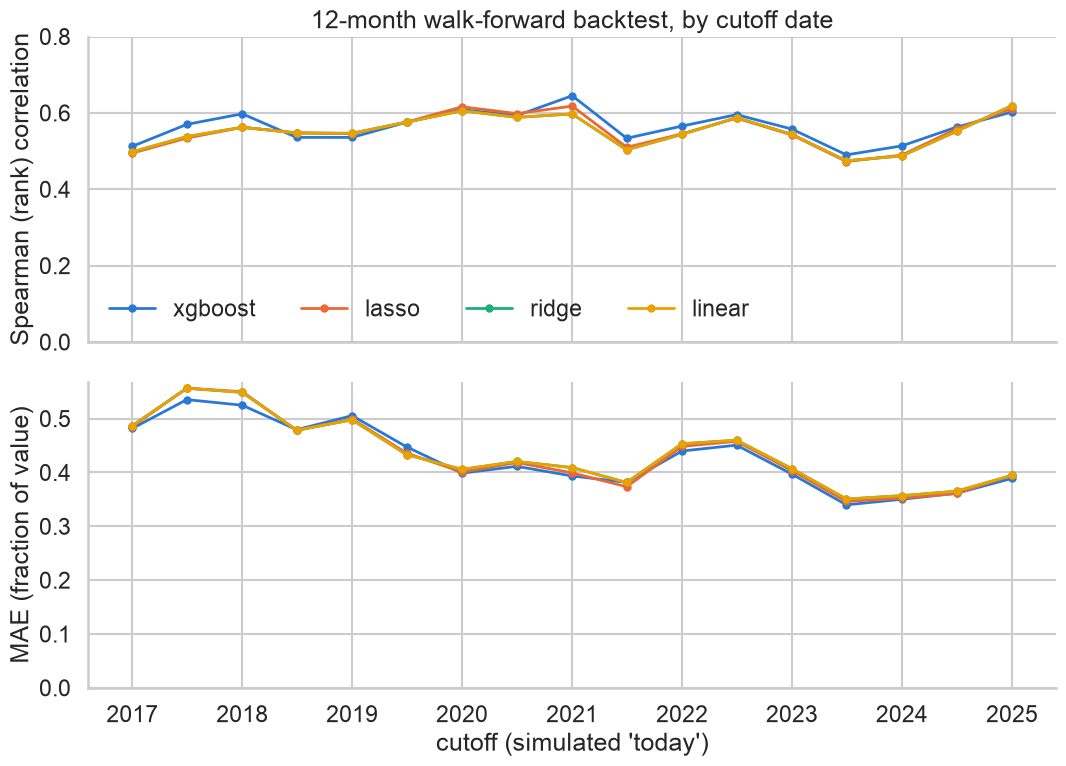

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for name in MODEL_ORDER:
    rows = metrics_12m[metrics_12m["model"] == name].sort_values("cutoff")
    axes[0].plot(rows["cutoff"], rows["spearman"], color=MODEL_COLORS[name], linewidth=2, marker="o", markersize=5, label=name)
    axes[1].plot(rows["cutoff"], rows["mae"], color=MODEL_COLORS[name], linewidth=2, marker="o", markersize=5, label=name)

axes[0].set_ylabel("Spearman (rank) correlation")
axes[0].set_ylim(0, 0.8)
axes[0].axhline(0, color="#444444", linewidth=0.8)
axes[0].set_title("12-month walk-forward backtest, by cutoff date")
axes[0].legend(frameon=False, ncol=4, loc="lower left")

axes[1].set_ylabel("MAE (fraction of value)")
axes[1].set_ylim(0, axes[1].get_ylim()[1])
axes[1].set_xlabel("cutoff (simulated 'today')")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Two things stand out. First, the ranking quality is fairly flat over time, in a band from about 0.49 to 0.65: no sign that the model only worked in one market regime. Second, MAE drifts down at the most recent cutoffs; that's partly more training data and partly a quieter market in the eval window (compare `mean_actual_all` in the metrics table), so it shouldn't be read as the model getting sharper.

## Does it hold for shorter horizons?

The same exercise for 3, 6, and 9 months, XGBoost only. Shorter horizons have fewer usable cutoffs because the panel matches short-horizon targets within a tighter tolerance window, so fewer snapshots ever get a 3-month outcome.

In [5]:
horizon_rows = []
for months in HORIZONS_MONTHS:
    cutoffs = default_backtest_cutoffs(panel, months=months)
    m, _ = walk_forward_backtest(panel, months=months, cutoffs=cutoffs, model_names=("xgboost",))
    m["months"] = months
    horizon_rows.append(m)
horizon_metrics = pd.concat(horizon_rows, ignore_index=True)

horizon_summary = horizon_metrics.groupby("months").agg(
    n_cutoffs=("cutoff", "size"),
    first_cutoff=("cutoff", "min"),
    last_cutoff=("cutoff", "max"),
    spearman_mean=("spearman", "mean"),
    spearman_min=("spearman", "min"),
    spearman_max=("spearman", "max"),
    mae_mean=("mae", "mean"),
    direction_accuracy=("direction_accuracy", "mean"),
)
horizon_summary.round({c: 3 for c in horizon_summary.columns if c.startswith(('spearman', 'mae', 'direction'))})

,n_cutoffs,first_cutoff,last_cutoff,spearman_mean,spearman_min,spearman_max,mae_mean,direction_accuracy
months,,,,,,,,
3,11,2021-01-01,2026-01-01,0.679,0.588,0.803,0.194,0.843
6,19,2016-09-01,2025-09-01,0.536,0.463,0.603,0.262,0.766
9,18,2016-11-01,2025-05-01,0.553,0.482,0.615,0.350,0.743
12,17,2017-01-01,2025-01-01,0.564,0.490,0.645,0.429,0.734


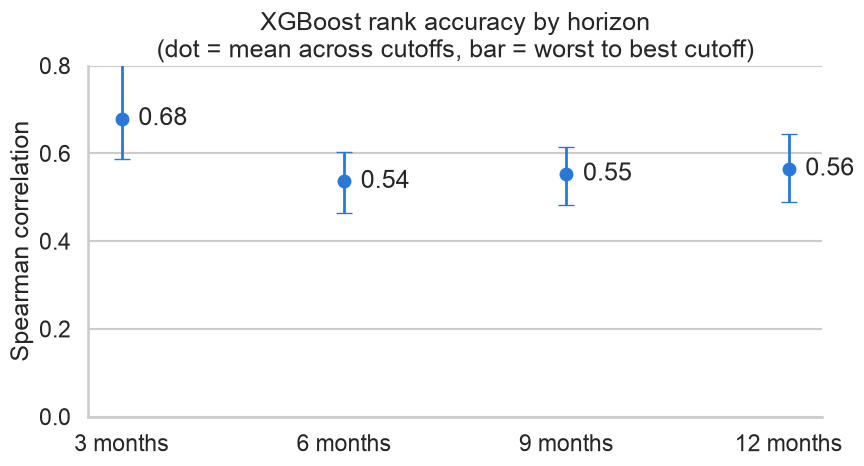

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(horizon_summary))
ax.errorbar(
    x,
    horizon_summary["spearman_mean"],
    yerr=[
        horizon_summary["spearman_mean"] - horizon_summary["spearman_min"],
        horizon_summary["spearman_max"] - horizon_summary["spearman_mean"],
    ],
    fmt="o",
    color=MODEL_COLORS["xgboost"],
    markersize=9,
    capsize=6,
    linewidth=2,
)
for xi, v in zip(x, horizon_summary["spearman_mean"]):
    ax.annotate(f"{v:.2f}", (xi, v), xytext=(12, 0), textcoords="offset points", va="center")
ax.set_xticks(x)
ax.set_xticklabels([f"{m} months" for m in horizon_summary.index])
ax.set_ylim(0, 0.8)
ax.set_ylabel("Spearman correlation")
ax.set_title("XGBoost rank accuracy by horizon\n(dot = mean across cutoffs, bar = worst to best cutoff)")
sns.despine(ax=ax)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Rank accuracy is about the same at every horizon. The error in *size* grows with the horizon, as it should: more can happen in twelve months than in three.

## Is the top of the list actually worth acting on?

A scout doesn't care about the correlation across all thousand-odd players; they care whether the handful the model flags most strongly really do rise. This compares the average realised change of the model's top 10% at each cutoff against the average across everyone.

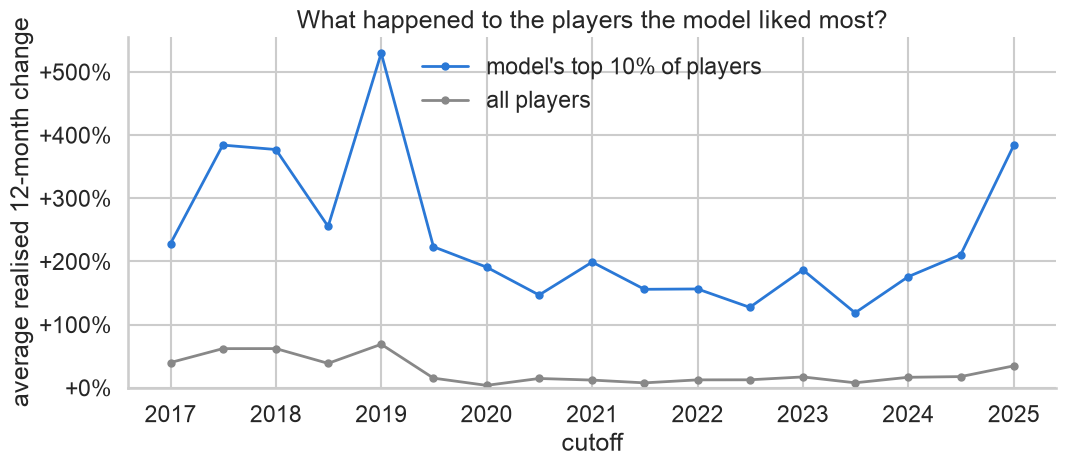

Top-decile players rose 10.8x more than the average player (median across cutoffs; worst cutoff 5.7x).


In [7]:
xgb_12m = metrics_12m[metrics_12m["model"] == "xgboost"].sort_values("cutoff")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xgb_12m["cutoff"], xgb_12m["mean_actual_top_decile"] * 100, color=MODEL_COLORS["xgboost"], linewidth=2, marker="o", markersize=5, label="model's top 10% of players")
ax.plot(xgb_12m["cutoff"], xgb_12m["mean_actual_all"] * 100, color="#888888", linewidth=2, marker="o", markersize=5, label="all players")
ax.set_ylabel("average realised 12-month change")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlabel("cutoff")
ax.set_title("What happened to the players the model liked most?")
ax.legend(frameon=False, loc="upper center")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

lift = (xgb_12m["mean_actual_top_decile"] / xgb_12m["mean_actual_all"])
print(f"Top-decile players rose {lift.median():.1f}x more than the average player (median across cutoffs; worst cutoff {lift.min():.1f}x).")

The players the model ranks in its top tenth grew several times more, on average, than the typical player, and that held at every single cutoff. This is the practical result: as a screening tool for "who is likely to rise", the model has been reliably useful. As a point forecast of *how much*, it hasn't.

## Can the sizing be fixed?

The first version of this notebook found the model called the *direction* well but undersized big moves, and blamed two design choices: training on a percentage-change target clipped at +500%, and a squared-error loss that a few breakouts dominate. This section tests the candidate fixes head to head, with the same walk-forward harness, for XGBoost with squared error and with a Huber loss:

- **raw % target, clip at 5x** (the original setup)
- **raw % target, clip at 20x** and **no clip** (let the model see the breakouts)
- **log-ratio target** `log(future / current)`, with and without the clip (symmetric in up/down moves, and it compresses breakouts so they stop dominating the loss)

In [8]:
configs = {
    "pct, clip 5x (original)": dict(target_transform="pct", clip=TARGET_CLIP),
    "pct, clip 20x": dict(target_transform="pct", clip=(-0.95, 20.0)),
    "pct, no clip": dict(target_transform="pct", clip=None),
    "log-ratio, clip 5x (default)": dict(target_transform="log_ratio", clip=TARGET_CLIP),
    "log-ratio, no clip": dict(target_transform="log_ratio", clip=None),
}
rows = []
for label, cfg in configs.items():
    m, _ = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=("xgboost", "xgboost_huber"), **cfg)
    per_model = m.groupby("model").agg(
        mae=("mae", "mean"),
        spearman=("spearman", "mean"),
        spearman_worst=("spearman", "min"),
        calibration_slope=("calibration_slope", "mean"),
        top_decile_predicted=("mean_predicted_top_decile", "mean"),
        top_decile_actual=("mean_actual_top_decile", "mean"),
    )
    per_model.insert(0, "config", label)
    rows.append(per_model.reset_index())
sizing = pd.concat(rows, ignore_index=True).set_index(["config", "model"])
sizing.round(3)

mae  spearman  spearman_worst  \
config                       model                                            
pct, clip 5x (original)      xgboost        0.483     0.543           0.464   
                             xgboost_huber  0.450     0.554           0.477   
pct, clip 20x                xgboost        0.547     0.529           0.448   
                             xgboost_huber  0.452     0.554           0.477   
pct, no clip                 xgboost        0.610     0.524           0.450   
                             xgboost_huber  0.452     0.555           0.477   
log-ratio, clip 5x (default) xgboost        0.429     0.564           0.490   
                             xgboost_huber  0.427     0.563           0.486   
log-ratio, no clip           xgboost        0.438     0.562           0.490   
                             xgboost_huber  0.431     0.561           0.485   

                                            calibration_slope  \
config                       model                              
pct, clip 5x (original)      xgboost                    0.815   
                             xgboost_huber              0.943   
pct, clip 20x                xgboost                    0.460   
                             xgboost_huber              0.856   
pct, no clip                 xgboost                    0.245   
                             xgboost_huber              0.856   
log-ratio, clip 5x (default) xgboost                    1.107   
                             xgboost_huber              1.113   
log-ratio, no clip           xgboost                    0.842   
                             xgboost_huber              0.926   

                                            top_decile_predicted  \
config                       model                                 
pct, clip 5x (original)      xgboost                       1.508   
                             xgboost_huber                 1.208   
pct, clip 20x                xgboost                       2.288   
                             xgboost_huber                 1.283   
pct, no clip                 xgboost                       2.838   
                             xgboost_huber                 1.282   
log-ratio, clip 5x (default) xgboost                       0.994   
                             xgboost_huber                 0.970   
log-ratio, no clip           xgboost                       1.234   
                             xgboost_huber                 1.108   

                                            top_decile_actual  
config                       model                             
pct, clip 5x (original)      xgboost                    2.398  
                             xgboost_huber              2.358  
pct, clip 20x                xgboost                    2.290  
                             xgboost_huber              2.344  
pct, no clip                 xgboost                    2.166  
                             xgboost_huber              2.365  
log-ratio, clip 5x (default) xgboost                    2.383  
                             xgboost_huber              2.356  
log-ratio, no clip           xgboost                    2.337  
                             xgboost_huber              2.349

The log-ratio target wins on every column at once: lowest error, highest and most stable rank correlation, and a calibration slope near 1 (1.1), i.e. the sizes of predicted moves are about right on average. It also makes the loss choice irrelevant (Huber and squared error land in the same place). It is now the default for every model in `src/modeling.py`, which is also why the linear models in the first table of this notebook do so much better than they did in notebook 02.

Letting the raw-percentage model see the breakouts is actively harmful: with the clip loosened or removed, the calibration slope collapses to 0.25-0.45, meaning the model starts predicting huge moves for many players who then don't deliver them. Huber loss softens that but doesn't fix it.

What *can't* be fixed is the last column. The average realised change of the model's top-decile picks is around +240%, against a prediction of around +100%, and that gap is driven by a few teenagers going from a few hundred thousand euros to tens of millions. Those are outliers no feature in this dataset foreshadows; a model that tried to predict them would (as the loosened-clip rows show) simply over-predict everyone else.

## Do more features help?

The original model knew a player's current value, age, trailing on-pitch output, team context, and transfer history. Three groups of features were added to the panel afterwards and are tested here walk-forward, at 12 months and at 3 months, for ridge and XGBoost:

- **Value trend**: the player's own valuation trajectory. The size of their last re-valuation, how long ago it was, and where the current value sits relative to their career peak so far.
- **Role and discipline**: share of trailing appearances that were starts, and cards per 90.
- **Club standing**: the club's league position after its most recent match as of the snapshot, how far through the season that standing is (so the off-season carries the final table), and whether the club sat in the relegation zone. The trailing-average club position smooths a whole year together; this is meant to catch a club sliding toward the drop, the bias notebook 06 finds in section 7.

A note on what is *not* here. Contract expiry is a well-known value driver, but the dataset only records each player's *current* contract, so for historical snapshots it would leak later extensions into training. It is carried through to notebook 02's predictions as context, not used as an input.

In [9]:
feature_sets = {
    "original": BASE_NUMERIC_FEATURES,
    "+ value trend": BASE_NUMERIC_FEATURES + VALUE_TREND_FEATURES,
    "+ role & discipline": BASE_NUMERIC_FEATURES + ROLE_FEATURES,
    "+ both": BASE_NUMERIC_FEATURES + VALUE_TREND_FEATURES + ROLE_FEATURES,
    "+ value trend + club standing": BASE_NUMERIC_FEATURES + VALUE_TREND_FEATURES + CLUB_STANDING_FEATURES,
}
ablation_rows = []
for months in (12, 3):
    cutoffs = default_backtest_cutoffs(panel, months=months)
    for label, features in feature_sets.items():
        m, _ = walk_forward_backtest(panel, months=months, cutoffs=cutoffs, model_names=("ridge", "xgboost"), numeric_features=features)
        per_model = m.groupby("model").agg(mae=("mae", "mean"), spearman=("spearman", "mean"), spearman_worst=("spearman", "min"), calibration_slope=("calibration_slope", "mean"))
        per_model.insert(0, "features", label)
        per_model.insert(0, "months", months)
        ablation_rows.append(per_model.reset_index())
ablation = pd.concat(ablation_rows, ignore_index=True).set_index(["months", "features", "model"])
ablation.round(3)

mae  spearman  spearman_worst  \
months features                      model                                      
12     original                      ridge    0.446     0.531           0.447   
                                     xgboost  0.446     0.527           0.432   
       + value trend                 ridge    0.436     0.548           0.473   
                                     xgboost  0.433     0.559           0.479   
       + role & discipline           ridge    0.446     0.530           0.446   
                                     xgboost  0.445     0.528           0.431   
       + both                        ridge    0.436     0.547           0.473   
                                     xgboost  0.433     0.558           0.479   
       + value trend + club standing ridge    0.436     0.551           0.475   
                                     xgboost  0.429     0.564           0.490   
3      original                      ridge    0.233     0.525           0.443   
                                     xgboost  0.206     0.596           0.485   
       + value trend                 ridge    0.226     0.588           0.508   
                                     xgboost  0.195     0.679           0.600   
       + role & discipline           ridge    0.233     0.523           0.444   
                                     xgboost  0.205     0.600           0.499   
       + both                        ridge    0.225     0.589           0.508   
                                     xgboost  0.195     0.679           0.595   
       + value trend + club standing ridge    0.225     0.590           0.512   
                                     xgboost  0.194     0.679           0.588   

                                              calibration_slope  
months features                      model                       
12     original                      ridge                1.207  
                                     xgboost              1.053  
       + value trend                 ridge                1.200  
                                     xgboost              1.094  
       + role & discipline           ridge                1.212  
                                     xgboost              1.061  
       + both                        ridge                1.206  
                                     xgboost              1.095  
       + value trend + club standing ridge                1.191  
                                     xgboost              1.107  
3      original                      ridge                1.145  
                                     xgboost              1.174  
       + value trend                 ridge                1.100  
                                     xgboost              1.154  
       + role & discipline           ridge                1.155  
                                     xgboost              1.161  
       + both                        ridge                1.108  
                                     xgboost              1.164  
       + value trend + club standing ridge                1.094  
                                     xgboost              1.170

The value-trend features are the biggest single improvement in this project: 12-month Spearman rises from about 0.53 to 0.56 and MAE falls by 3%, and at 3 months Spearman jumps from 0.60 to 0.68. Momentum in a player's own valuation is informative about the next move, and the model didn't previously know it. Role and discipline add nothing at either horizon, so they're built into the panel but left out of the default feature set.

Club standing is a smaller, second-order gain, and only for XGBoost: on top of the value-trend features it trims 12-month MAE by about 1% and lifts 12-month Spearman by half a hundredth, and does nothing at 3 months. Ridge doesn't move, which fits: the useful part is the interaction between a low position and a season that is nearly over, which a linear model can't express. The features are only populated from the 2012-13 season, when the match data begins, so the earliest cutoffs can't benefit. Notebook 06 section 7 checks whether the gain lands where it was aimed, on players at clubs that go down. Both groups are now part of the default, which is why the first table in this notebook (which uses the defaults) scores a little higher than the "original" rows here.

## Does tuning the hyper-parameters help?

Every model so far used hard-coded settings (`alpha=1.0` for ridge, `alpha=0.01` for lasso, 300 trees of depth 4 for XGBoost). `tune_model` in `src/modeling.py` replaces those with a small grid search, cross-validated with time-ordered folds inside each cutoff's training data, so the tuning itself can't peek at the evaluation window. Same walk-forward comparison, tuned against default:

In [10]:
tunable = ("ridge", "lasso", "xgboost")
tuned_metrics, _ = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=tunable, tune=True)
default_metrics = metrics_12m[metrics_12m["model"].isin(tunable)].copy()
tuned_metrics["setting"], default_metrics["setting"] = "tuned", "default"

tuning = (
    pd.concat([default_metrics, tuned_metrics])
    .groupby(["model", "setting"])
    .agg(mae=("mae", "mean"), spearman=("spearman", "mean"), spearman_worst=("spearman", "min"), calibration_slope=("calibration_slope", "mean"))
)
tuning.round(3)

mae  spearman  spearman_worst  calibration_slope
model   setting                                                    
lasso   default  0.433     0.553           0.473              1.318
        tuned    0.434     0.554           0.476              1.258
ridge   default  0.436     0.551           0.475              1.191
        tuned    0.433     0.552           0.473              1.260
xgboost default  0.429     0.564           0.490              1.107
        tuned    0.426     0.569           0.494              1.318

Tuning changes almost nothing for the linear models and buys XGBoost a few thousandths of MAE and about half a hundredth of Spearman, at the cost of calibration (slope 1.11 to 1.32): the tuned trees are shallower and fewer, which shrinks every prediction toward the average. That's what optimising MAE does, since a more timid forecast is usually a lower-MAE forecast on noisy data. The hard-coded defaults were already about as good as this feature set allows, and better calibrated, so tuning stays available (`tune=True`) but off by default.

## Saying how sure we are: prediction intervals

Given a point forecast is only reliable to within a wide band, an honest output is the band itself. Quantile regression gives a 10th and 90th percentile prediction per player; if those are calibrated, the real outcome should land inside the band about 80% of the time. This checks that walk-forward, too.

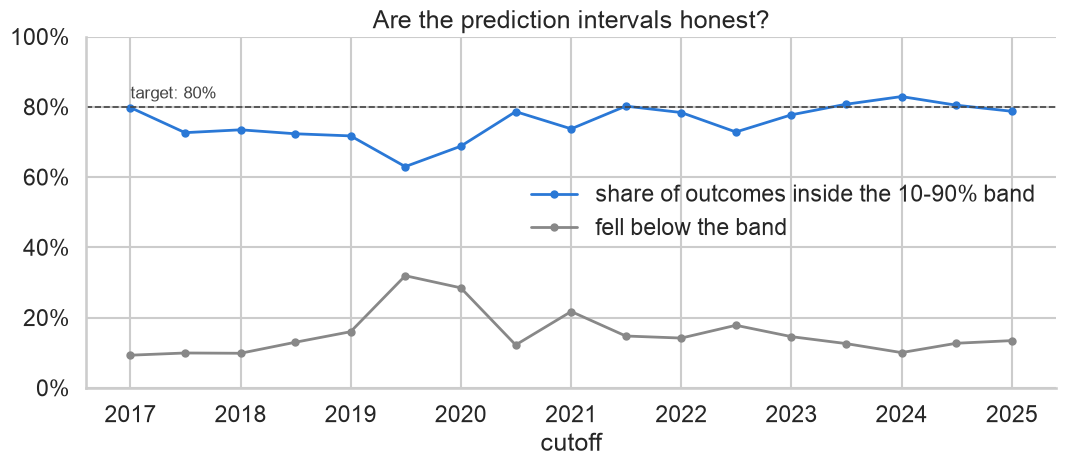

Mean coverage across cutoffs: 76% (target 80%); median band width 91% of current value.


In [11]:
interval_12m = walk_forward_interval_backtest(panel, months=12, cutoffs=cutoffs_12m, quantiles=(0.1, 0.9))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(interval_12m["cutoff"], interval_12m["coverage"] * 100, color=MODEL_COLORS["xgboost"], linewidth=2, marker="o", markersize=5, label="share of outcomes inside the 10-90% band")
ax.plot(interval_12m["cutoff"], interval_12m["below_low"] * 100, color="#888888", linewidth=2, marker="o", markersize=5, label="fell below the band")
ax.axhline(80, color="#444444", linestyle="--", linewidth=1.2)
ax.annotate("target: 80%", (interval_12m["cutoff"].iloc[0], 80), xytext=(0, 6), textcoords="offset points", fontsize=12, color="#444444")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0f}%")
ax.set_xlabel("cutoff")
ax.set_title("Are the prediction intervals honest?")
ax.legend(frameon=False, loc="center right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Mean coverage across cutoffs: {interval_12m['coverage'].mean():.0%} (target 80%); median band width {interval_12m['median_width'].median():.0%} of current value.")

Coverage sits a little under the 80% target on average, and the miss is concentrated in two cutoffs: mid-2019 and early 2020. In both, far more players fell *below* the band than the model expected. Those are the evaluation windows that include the pandemic, when Transfermarkt marked down valuations across the board in spring 2020. Nothing in a player's own history could have predicted a market-wide cut, so the intervals were wrong in exactly the way one would expect. Outside those windows the band is close to honest.

The median band is roughly as wide as the player's current value, which is the real answer to "how precisely can this be predicted": to within about plus or minus half the current value, most of the time.

## Case study: June 2025

The single rollback the first version of this notebook used, kept as a worked example of what one cutoff looks like underneath the summary numbers. Note this cutoff is later than the last default one: some players' 12-month outcomes hadn't been re-valued by the end of the data, so the eval set is a little smaller and possibly biased toward players who *did* get re-valued.

Trained on 25,567 snapshots, evaluated on 771 players.
MAE 0.39 | Pearson 0.50 | Spearman 0.60 | direction right 74%


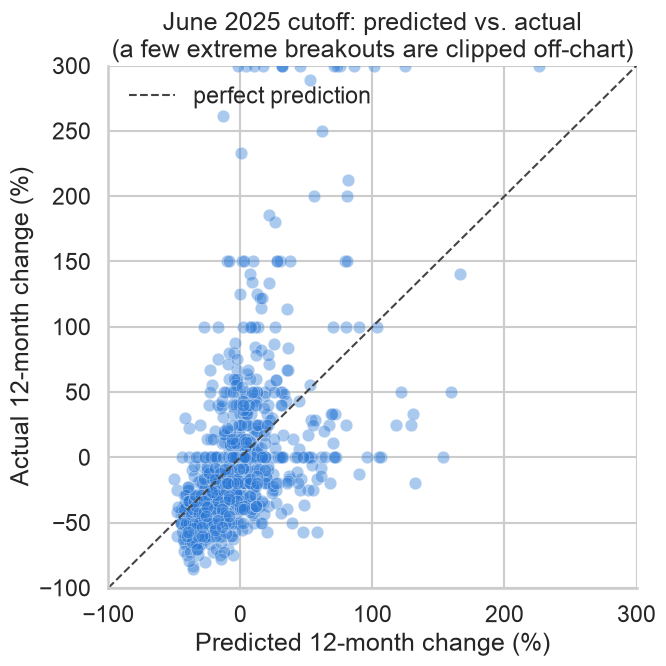

In [12]:
case_metrics, case_preds = walk_forward_backtest(
    panel, months=12, cutoffs=[pd.Timestamp("2025-06-01")], model_names=("xgboost",)
)
case = case_preds.copy()
row = case_metrics.iloc[0]
print(f"Trained on {row['n_train']:,} snapshots, evaluated on {row['n_eval']} players.")
print(f"MAE {row['mae']:.2f} | Pearson {row['pearson']:.2f} | Spearman {row['spearman']:.2f} | direction right {row['direction_accuracy']:.0%}")

plot_data = case.copy()
plot_data["predicted"] = plot_data["predicted_pct_change"].clip(-1, 3) * 100
plot_data["actual"] = plot_data["actual_pct_change"].clip(-1, 3) * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_data["predicted"], plot_data["actual"], alpha=0.4, color=MODEL_COLORS["xgboost"], edgecolor="white", linewidth=0.5)
lims = [-100, 300]
ax.plot(lims, lims, color="#444444", linestyle="--", linewidth=1.5, label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Predicted 12-month change (%)")
ax.set_ylabel("Actual 12-month change (%)")
ax.set_title("June 2025 cutoff: predicted vs. actual\n(a few extreme breakouts are clipped off-chart)")
ax.legend(loc="upper left", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [13]:
top10 = case.sort_values("predicted_pct_change", ascending=False).head(10).copy()
top10["Predicted change"] = (top10["predicted_pct_change"] * 100).round(0).astype(int).map("{:+d}%".format)
top10["Actual change"] = (top10["actual_pct_change"] * 100).round(0).astype(int).map("{:+d}%".format)
top10 = top10.rename(columns={"name": "Player", "sub_position": "Position"})
top10[["Player", "Position", "Predicted change", "Actual change"]].reset_index(drop=True)

,Player,Position,Predicted change,Actual change
0,Josh King,Attacking Midfield,+226%,+2400%
1,Harrison Armstrong,Central Midfield,+166%,+140%
2,Louie Marsh,Second Striker,+160%,+50%
3,Omari Kellyman,Attacking Midfield,+154%,+0%
4,Eric da Silva Moreira,Right-Back,+132%,-20%
5,James Carragher,Centre-Back,+131%,+33%
6,Ben Nelson,Centre-Back,+129%,+25%
7,Alysson,Right Winger,+124%,+3100%
8,Tyler Bindon,Centre-Back,+121%,+50%
9,Chris Rigg,Attacking Midfield,+118%,+25%


The same pattern the summary shows, at the level of named players. Eight of the top ten rose, though mostly by less than predicted; two (Josh King and Alysson) rose by an order of magnitude more; one didn't move at all and one fell. Two things to notice. The names are almost all teenagers on tiny valuations, because the biggest *percentage* gains are only possible from a low base, so the "% risers" list is really a list of academy prospects. And the model undersizes genuine breakouts, which is consistent with training on a clipped target and a squared-error loss.

## Caveats

- The evaluation set at each cutoff is players who *did* get re-valued near the target date, in any league Transfermarkt tracks (players who left the Premier League keep their outcome; notebook 06 section 4 shows this lowers the headline by about 0.03 Spearman against a PL-only evaluation). Players who went un-valued for a long stretch, mostly the cheap, unused fringe, aren't represented, so the numbers describe "players still being tracked" rather than every player.
- Cutoffs six months apart share most of their training data, so the 17 cutoffs are not 17 independent trials. They are, however, 17 genuinely different evaluation windows, which is what matters for "did it work in different years".
- Everything the model can't see (injuries, contract situations, transfer speculation, managerial change) is exactly what drives the biggest misses, and none of it is in the features.